In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

plotsdir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/Plots/'


import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [17]:
#Data:
Avtaus =[30283.333333333332, 33860.0, 42693.333333333336, 67960.0, 91480.0, 167493.33333333334] 
Stdtaus= [5380.020652583243, 3260.306734035925, 3336.9879965155537, 3341.766000186129, 8903.441282260846, 31526.95495744695]
TurnoverOG =  [16.43266169 ,20.33251425,17.73810651 ,24.73333548 ,33.1258946  ,59.25860059] 
TurnoverErrorOG= [0.77185855, 0.17864447,0.688598,   1.37802383 ,1.55088175 ,1.06487754]
#Avtaus =[22483.333333333332, 36940.0, 38563.333333333336, 78500.0, 90313.33333333333, 190603.33333333334] 
#Stdtaus= [2923.2896233904403, 6006.535329677722, 3007.394590375899, 16220.519925904553, 26238.262561042837, 80438.4192341501] 
#TurnoverOG = [14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]
#TurnoverErrorOG=[0.02153922135383837, 0.7248736871105754, 0.8129193999286023, 1.1557439454442404, 1.3577575845457819, 6.299237673061252]

# TurnoverDome = [ 20.66170066  ,31.58484161 , 35.76302981 , 66.6755884 ,  81.34243028, 156.88420561]
# TurnoverErrorDome=[ 0.9560511 ,  2.41557375 , 3.76090112 , 4.30833404 , 5.30865171, 27.12915161]
# Dometaus = [ 32240.    ,      36550.       ,   40980.      ,    72313.33333333,  91186.66666667 ,177980.        ] #[ 31980.,  34880. , 44140.,  67860.,  99980. ,203360.]
# StdDometaus= [  260.     ,     1670.    ,      2238.27314389 , 3212.73853416, 11187.02025663 ,    0.        ]


TurnoverDome = [ 22.72239815,  36.5295393 ,  40.83164218 , 68.06745266 , 80.42616011, 153.28827388]
TurnoverErrorDome = [ 1.29313468 , 3.77518125 , 5.19161874 ,10.56862748  ,7.07079983 ,19.403169  ] #[ 19.85123265 , 35.02019844 , 40.8739017 ,  68.22514254 , 82.22431073, 192.60845566]
Dometaus =[ 31306.66666667 , 36406.66666667 , 40840.   ,       66520.,94226.66666667, 187900.        ] #[ 31980.,  34880. , 44140.,  67860.,  99980. ,203360.]
StdDometaus = [3717.71734028 ,1206.79557323 , 510.16337253 ,6380.53289311, 5182.54334816, 7940.    ]

In [18]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

# Measuring turmnover during equilibration

## Inlcuding original

Slope OG: 3185.849192793947 intercept: -0.01883149744995847
Slope Dome: 1249.5265219447379 intercept: -0.007490259728423144


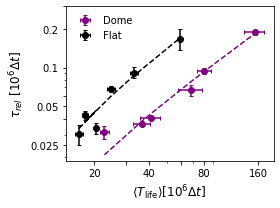

In [19]:
fig,ax = plt.subplots(figsize = (4,3))
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
#for f in range(len(MP)):
#make a linear fit to the data
x,y = np.array(TurnoverOG),np.array(Avtaus)
# linear fir of y with y=mc+c
m, b = np.polyfit(x, y, 1)
x2,y2 = np.array(TurnoverDome),np.array(Dometaus)
m2, b2 = np.polyfit(x2, y2, 1)
#12 = x.transpose()
#Make a transpose of the x data
x12 = x.reshape(-1,1)
a, _, _, _ = np.linalg.lstsq(x12, y)
x22 = x2.reshape(-1,1)
a2, _, _, _ = np.linalg.lstsq(x22, y2)
ax.plot(x, np.divide(np.add(np.multiply(m,x), b),10**6),linestyle = '--',color = "black")
#ax.plot(x, np.divide(np.add(np.multiply(a,x12), 0),10**6),linestyle = '--',color = "#d95f0e")
#ax.plot(x2, np.divide(np.add(np.multiply(a2,x2), 0),10**6),linestyle = '--',color = "purple")
ax.plot(x2, np.divide(np.add(np.multiply(m2,x2), b2),10**6),linestyle = '--',color ='purple')
ax.errorbar(TurnoverDome[:],np.divide(Dometaus[:],10**6), xerr = TurnoverErrorDome[:],yerr = np.divide(StdDometaus[:],10**6),capsize = 2,linestyle = '',color = 'purple',marker = 'o',markersize = 6,label = 'Dome') ##Would this by x2??
ax.errorbar(TurnoverOG[:],np.divide(Avtaus[:],10**6), xerr = TurnoverErrorOG[:],yerr = np.divide(Stdtaus[:],10**6),capsize = 2,linestyle = '',color = "black",marker = 'o',markersize = 6,label = 'Flat') ##Would this by x2??
#ax.plot([35,250],[0.015,0.08],linestyle = '--',color = 'black') #ClrsOrange[3])
#ax.plot([40,300],[0.0005*25,0.0005*230],linestyle = '--',color = 'purple')## add original 
#ax.plot([17,300],[0.0005*20,0.0005*300],linestyle = '--',color = "#d95f0e")

print('Slope OG:',m, 'intercept:',b/10**6)
print('Slope Dome:',m2, 'intercept:',b2/10**6)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$\tau_{rel}$ [$10^6\Delta t$]",fontsize = 12)
ax.legend(frameon=False)
ax.set_xticks([20,30,40,60,80,160],['20','','40','','80','160'])
ax.set_yticks([0.025,0.04,0.05,0.06,0.1,0.2,0.3],['0.025','','0.05','','0.1','0.2',''])
plotname = 'DomeMasterFig.pdf'
fig.tight_layout()
fig.savefig(plotsdir+plotname)